    soil_nitrogen    rainfall  temperature  water_usage
0       74.967142  632.408397    17.923146   420.039428
1       68.617357  561.491772    22.896773   427.715857
2       76.476885  532.307800    23.286427   345.598022
3       85.230299  661.167629    20.988614   418.580296
4       67.658466  703.099952    24.193571   423.445798
5       67.658630  693.128012    27.020254   342.851887
6       85.792128  516.078248    34.430930   549.261961
7       77.674347  569.078762    25.872889   437.906634
8       65.305256  633.126343    26.287752   304.695720
9       75.425600  697.554513    24.627770   452.524289
10      65.365823  552.082576    15.406144   322.025466
11      65.342702  581.434102    24.867431   462.966768
12      72.419623  489.366503    25.301151   492.687646
13      50.867198  480.379338    37.316211   334.345415
14      52.750822  681.252582    24.038195   477.070090
15      64.377125  735.624003    26.507737   433.022474
16      59.871689  592.798988    24.826441   465

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3500 - loss: 0.8902   
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4000 - loss: 0.8629 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4250 - loss: 0.8360 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 0.8086 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.7873 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.7652 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6500 - loss: 0.7471 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6750 - loss: 0.7314 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6750 - loss: 0.7157 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.7020 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6895 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6782 
Epoch 13/5

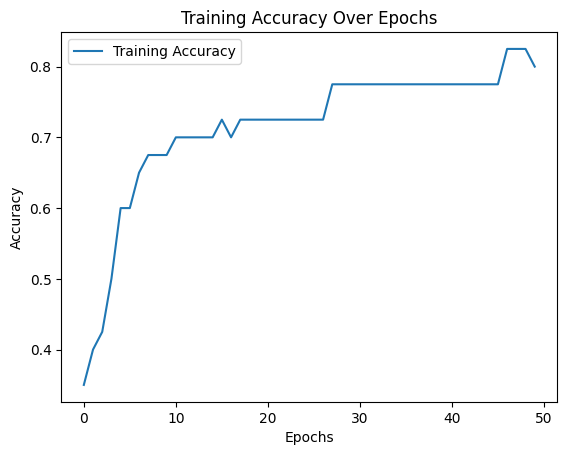

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#1 generate dataset  50 samples
np.random.seed(42)
n_samples=50

data=pd.DataFrame({
    'soil_nitrogen':np.random.normal(70, 10, n_samples),
    'rainfall':np.random.normal(600, 100, n_samples),
    'temperature':np.random.normal(25, 5, n_samples),
    'water_usage':np.random.normal(400, 80, n_samples)
})

print(data)

#create classification label(h=1:uh=0)
data['Label']=(
    (data['soil_nitrogen']>65)&
    (data['rainfall']>550)&
    (data['water_usage']>350)
).astype(int)

#2 split features amd labels
X=data.drop('Label',axis=1)
y=data['Label']

#3 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#4 feature scaling
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#5 build ANN model

model=Sequential()

#input+hidden layers

model.add(Dense(8, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(6, activation='relu'))

#output layer (BC)
model.add(Dense(1, activation='sigmoid'))

#6 compile model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#7 train model
history=model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=5,
    verbose=1
)

#8 predictions

y_pred= model.predict(X_test)
y_pred= (y_pred>0.5).astype(int)

#9 evaluation metrics

print('\n---Model Evaluation---')

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

#10 plot training performance

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.show()











